In [ ]:
import random

def MontyHall_sim(schimba_usa=False, n_sim=1, afisare=False):
    wins = 0

    # Lista de uși și simboluri
    usi = [0, 1, 2]
    simboluri = {0: '🐐', 1: '🚗'} # 0 = Capră, 1 = Mașină

    for i in range(n_sim):
        # i) Poziționare aleatoare
        # Creăm o listă cu o mașină (1) și două capre (0)
        asezare = [0, 0, 0]
        poz_masina = random.randint(0, 2)
        asezare[poz_masina] = 1

        # ii) Alegerea jucătorului
        alegere_initiala = random.randint(0, 2)

        # iii) Moderatorul deschide o ușă cu capră
        # Trebuie să fie diferită de alegerea jucătorului și să aibă o capră
        posibile_deschideri = [u for u in usi if u != alegere_initiala and asezare[u] == 0]
        usa_deschisa = random.choice(posibile_deschideri)

        # iv) Schimbarea sau păstrarea
        alegere_finala = alegere_initiala
        if schimba_usa:
            # Alege ușa rămasă (nici cea inițială, nici cea deschisă)
            alegere_finala = [u for u in usi if u != alegere_initiala and u != usa_deschisa][0]

        # Verificăm rezultatul
        if asezare[alegere_finala] == 1:
            wins += 1
            rezultat = "SUCCES!"
        else:
            rezultat = "EȘEC!"

        if afisare and n_sim == 1:
            # Afișăm detaliile vizuale (doar pentru o singură simulare)
            str_asezare = " ".join([simboluri[x] for x in asezare])
            # Marcăm alegerile vizual
            viz_init = ["🚪"] * 3
            viz_init[alegere_initiala] = "👇"

            print(f"Așezarea:        {str_asezare}")
            print(f"Prima alegere:   Ușa {alegere_initiala+1}")
            print(f"Capra dezvăluită: Ușa {usa_deschisa+1}")
            if schimba_usa:
                print(f"A doua alegere:  Ușa {alegere_finala+1} (S-a schimbat)")
            else:
                print(f"A doua alegere:  Ușa {alegere_finala+1} (A rămas)")
            print(f"Rezultat:        {rezultat}")

    if n_sim > 1:
        probabilitate = wins / n_sim
        actiune = "Schimbă ușa" if schimba_usa else "Păstrează ușa"
        print(f"Strategie: {actiune} | Câștiguri: {wins}/{n_sim} | Probabilitate: {probabilitate:.4f}")

# Testăm funcția conform cerinței
print("--- Simulare Vizuală (Nu schimbă) ---")
MontyHall_sim(schimba_usa=False, n_sim=1, afisare=True)
print("\n--- Simulare Vizuală (Schimbă) ---")
MontyHall_sim(schimba_usa=True, n_sim=1, afisare=True)

print("\n--- Estimare Probabilități (10.000 simulări) ---")
MontyHall_sim(schimba_usa=False, n_sim=10000)
MontyHall_sim(schimba_usa=True, n_sim=10000)

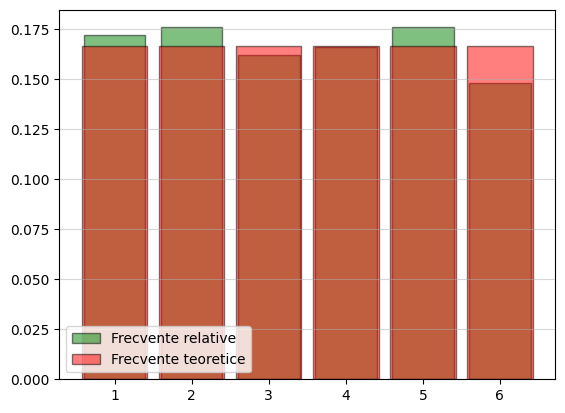

In [1]:
from random import randrange
from matplotlib.pyplot import bar, hist, grid, show, legend, figure

data = [randrange(1, 7) for _ in range(500)]

bin_edges = [k + 0.5 for k in range(7)]

hist(data, bin_edges, density=True, rwidth=0.8, color='green', edgecolor='black', alpha=0.5, label='Frecvente relative')

distribution = dict((i, 1/6) for i in range(1, 7))
bar(distribution.keys(), distribution.values(), width=0.85,
    color='red', edgecolor='black', alpha=0.5, label='Frecvente teoretice')

legend(loc='lower left')
grid(axis='y', alpha=0.5)
show()